# Heatwave Risk Assessment — Astana, Kazakhstan
**CLIMAAX Heatwave Risk (satellite-derived) workflow adapted for Kazakhstan**

- Based on the CLIMAAX [Handbook](https://handbook.climaax.eu/) HEATWAVES risk workflow
- Risk = Exposure (Landsat LST heat islands) × Vulnerability (WorldPop age-stratified population)


---
## Data Substitutions

| Original (CLIMAAX EU) | Kazakhstan replacement |
|---|---|
| Climate-ADAPT trend links (EU/NUTS2 only) | Reference to Kazakhstan hazard notebook outputs |
| RSLab Landsat 8 LST portal | Same — global coverage, works for Astana ✓ |
| WorldPop age-stratified population | Same — global coverage, Kazakhstan files (`kaz_*`) ✓ |
| Zilína CI shapefile (`ci_features_ZA.shp`) | OSM amenity features via `osmnx` (automated) |
| `localtileserver` interactive map | Static `matplotlib` + `contextily` maps |

## Vulnerability framing

This workflow uses **WorldPop age-stratified** files (elderly ≥ 65 y and children ≤ 1 y)
so the vulnerability layer represents at-risk age groups, not total population.
Risk map answers: **"Where are the most heat-exposed vulnerable people in Astana?"**


## Step 0: Configuration


In [1]:
from pathlib import Path

LON_MIN = 71.30
LON_MAX = 71.65
LAT_MIN = 51.08
LAT_MAX = 51.28
LOCATION_NAME = "Astana"

LST_BINS   = [20, 25, 30, 35, 40, 45, 50, 55, 60]
LST_VALUES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

CRIT_INFRA_TAGS = [
    "hospital", "clinic", "pharmacy",
    "police", "fire_station",
    "school", "university", "kindergarten",
]
CRIT_MARKERS = {
    "hospital":     {"marker": "P", "color": "red"},
    "clinic":       {"marker": "P", "color": "salmon"},
    "pharmacy":     {"marker": "+", "color": "purple"},
    "police":       {"marker": "s", "color": "blue"},
    "fire_station": {"marker": "X", "color": "pink"},
    "school":       {"marker": "o", "color": "green"},
    "university":   {"marker": "^", "color": "darkgreen"},
    "kindergarten": {"marker": "o", "color": "lime"},
}

WORKFLOW_FOLDER = Path("Heatwave_risk_KZ")
DATA_DIR        = WORKFLOW_FOLDER / "data"
LST_DIR         = DATA_DIR / "LST"
POP_DIR         = DATA_DIR / "population"
OSM_DIR         = DATA_DIR / "osm"
RESULTS_DIR     = WORKFLOW_FOLDER / "results"

## Step 1: Imports and Setup


In [2]:
import warnings
import zipfile
from glob import glob
from datetime import datetime

import numpy as np
import xarray as xr
import pandas as pd
import rasterio
import rioxarray
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import plotly.express as px

warnings.filterwarnings("ignore")
for d in [WORKFLOW_FOLDER, DATA_DIR, LST_DIR, POP_DIR, OSM_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Directories ready under: {WORKFLOW_FOLDER.resolve()}")

Directories ready under: C:\Users\dauzo\Models\crabook-kazakhstan\crabook\notebooks\workflows\HEATWAVES\01_Urban_heatwaves\Heatwave_risk_KZ


## Step 2: Climate Trends Context

Before identifying urban heat islands, it is useful to understand how
heatwave occurrence in Astana is projected to change under climate change.

**Use the outputs from the Kazakhstan Heatwave Hazard notebook** (`heatwave_hazard_xclim_kz.py`):
- HWI / HWF / HWTL bar charts for Astana under SSP1-2.6 and SSP3-7.0
- Saved to `Heatwave_hazard_XCLIM_KZ/results/`

The hazard notebook shows that Astana is projected to experience a significant
increase in annual heatwave days toward the end of the 21st century,
particularly under SSP3-7.0. This contextualises the urban-scale risk map
produced below.


## Step 3: Land Surface Temperature (LST) Data

:::{note}
Option 2 (automated Landsat download via eodag + pylandtemp) is not included in this adaptation. Use the RSLab portal (Option 1) below.
:::

### Manual download instructions — RSLab portal

LST data must be downloaded manually from the RSLab portal:
**https://rslab.gr/Landsat_LST.html**

Steps:
1. Open the portal. Use the **drawing tool on the map** to draw a bounding box
   around your area of interest (Astana urban core). Zoom in first for accuracy.
   If you get a "Very big request" error, reduce the box size slightly.
2. Select a **broad time period** to maximise the number of cloud-free images,
   e.g. **May 1 → September 30** across **multiple years** (e.g. 2019–2023).
   Landsat has an 8–16 day revisit — a wider window gives more valid scenes.
   The cloud-filtering step later (≥ 50 % valid pixels) will automatically
   discard heavily clouded images, so downloading more is better.
3. Source: **Landsat 8 or 9**; Emissivity: **MODIS and NDVI-based**
4. Click **"Calculate LST"**, then **"Download — All images"**
5. Move the downloaded `AllImages_LST.zip` to:
   `Heatwave_risk_KZ/data/LST/`

💡 **Tip**: If the portal is slow or times out, download one year at a time
and place each extracted zip in the LST folder — the unzip cell below handles
multiple zips automatically.

⚠️ **Note on surface vs air temperature**: LST is the ground surface
temperature, which can exceed air temperature by 10–15 °C on sunny days.
The classification thresholds in Step 4 are set accordingly.


In [3]:
for f in LST_DIR.iterdir():
    if f.suffix == ".zip" and zipfile.is_zipfile(f):
        with zipfile.ZipFile(f, "r") as z:
            z.extractall(LST_DIR)
        print(f"Extracted: {f.name}")

lst_files = sorted(LST_DIR.glob("*LST*.tif"))
print(f"Found {len(lst_files)} LST file(s) in {LST_DIR}")
if not lst_files:
    print("⚠ No LST files found. Follow the download instructions above before continuing.")

Found 52 LST file(s) in Heatwave_risk_KZ\data\LST


### Extract dates from LST filenames


In [4]:
lst_dates = []
for f in lst_files:
    name = f.name
    if "AllImages_LST" in name:
        parts    = name.split(".")
        date_str = parts[1].split("_")[0]
        time_str = parts[1].split("_")[1]
    else:
        date_str = name[4:12]
        time_str = name[13:19]
    lst_dates.append(datetime.strptime(date_str + "_" + time_str, "%Y%m%d_%H%M%S"))

print("LST acquisition dates:")
for d in lst_dates:
    print(f"  {d:%Y-%m-%d %H:%M:%S}")

LST acquisition dates:
  2020-08-03 06:08:03
  2020-08-03 06:08:27
  2021-06-28 06:01:48
  2021-06-28 06:02:12
  2021-07-21 06:08:04
  2021-07-28 06:14:42
  2021-07-30 06:01:57
  2021-07-30 06:02:21
  2021-08-06 06:08:35
  2021-08-31 06:02:32
  2022-06-07 06:01:51
  2022-06-22 06:08:43
  2022-06-23 06:01:45
  2022-07-15 06:14:53
  2022-07-25 06:02:17
  2022-08-24 06:14:30
  2022-08-24 06:14:54
  2022-08-25 06:08:38
  2022-08-25 06:09:02
  2023-06-01 06:07:58
  2023-06-02 06:01:14
  2023-06-02 06:01:37
  2023-06-16 06:13:44
  2023-06-16 06:14:08
  2023-06-18 06:01:47
  2023-07-10 06:13:51
  2023-07-10 06:14:15
  2023-07-11 06:07:48
  2023-07-11 06:08:11
  2023-07-19 06:07:42
  2023-08-03 06:14:32
  2023-08-05 06:02:10
  2023-08-19 06:14:14
  2023-08-20 06:08:18
  2023-08-21 06:02:17
  2024-06-19 06:07:14
  2024-06-20 06:01:31
  2024-06-27 06:07:47
  2024-07-12 06:13:41
  2024-07-30 06:01:23
  2024-07-30 06:01:47
  2025-06-05 06:13:44
  2025-06-05 06:14:08
  2025-06-06 06:07:31
  2025-06

### Build raster stack from all LST files


In [5]:
stack_path = DATA_DIR / "L8_raster_stack.tif"

if stack_path.exists():
    print(f"Cached: {stack_path.name}")
elif not lst_files:
    print("⚠ No LST files found — cannot build stack. "
          "Place downloaded .tif files in LST_DIR and re-run Step 3.")
else:
    with rasterio.open(lst_files[0]) as src0:
        meta = src0.meta.copy()
    meta.update(count=len(lst_files))
    with rasterio.open(stack_path, "w", **meta) as dst:
        for idx, layer in enumerate(lst_files, start=1):
            with rasterio.open(layer) as src:
                dst.write_band(idx, src.read(1))
    print(f"Saved: {stack_path.name}")

Cached: L8_raster_stack.tif


### Calculate mean LST values (cloud-filtered)

Only dates where ≥ 50 % of pixels have valid (> 0) values are used.


In [6]:
if not stack_path.exists():
    raise FileNotFoundError("Stack not built yet — place LST .tif files in LST_DIR and re-run Steps 3–4.")

raster_ds = xr.open_dataset(stack_path)
num_valid  = (raster_ds > 0).sum(dim=("x", "y"))
total_px   = raster_ds.sizes["x"] * raster_ds.sizes["y"]
prop_valid = num_valid / total_px

filtered        = raster_ds.where(prop_valid >= 0.5)
mean_filtered   = filtered.mean(dim=("x", "y"))["band_data"]
mean_values_lst = mean_filtered.values.tolist()

print(f"Dates with < 50 % cloud cover: "
      f"{sum(v > 0 for v in mean_values_lst)}/{len(mean_values_lst)}")

Dates with < 50 % cloud cover: 9/52


### Plot LST mean values over time


In [7]:
df_lst = pd.DataFrame({"Date": lst_dates, "LST_mean": mean_values_lst})
fig = px.scatter(
    df_lst, x="Date", y="LST_mean",
    labels={"Date": "Date", "LST_mean": "LST Mean (°C)"},
    title="Mean Land Surface Temperature per Landsat image (cloud cover < 50%)",
    color="LST_mean",
    color_continuous_scale="Reds",
)
fig.update_layout(title_x=0.5)
fig.update_xaxes(tickformat="%d-%m-%Y")
fig.show()

## Step 4: Classify LST (Exposure Layer)

Maximum LST across all valid images is reclassified into 10 exposure classes:

| Class | LST range | Exposure level |
|---|---|---|
| 1–2 | < 25 °C | Very Low |
| 3–4 | 25–35 °C | Low |
| 5–6 | 35–45 °C | Medium |
| 7–8 | 45–55 °C | High |
| 9–10 | > 55 °C | Very High |

⚠️ Adjust `LST_BINS` in Step 0 if your Astana images show surface
temperatures outside the 20–60 °C range.


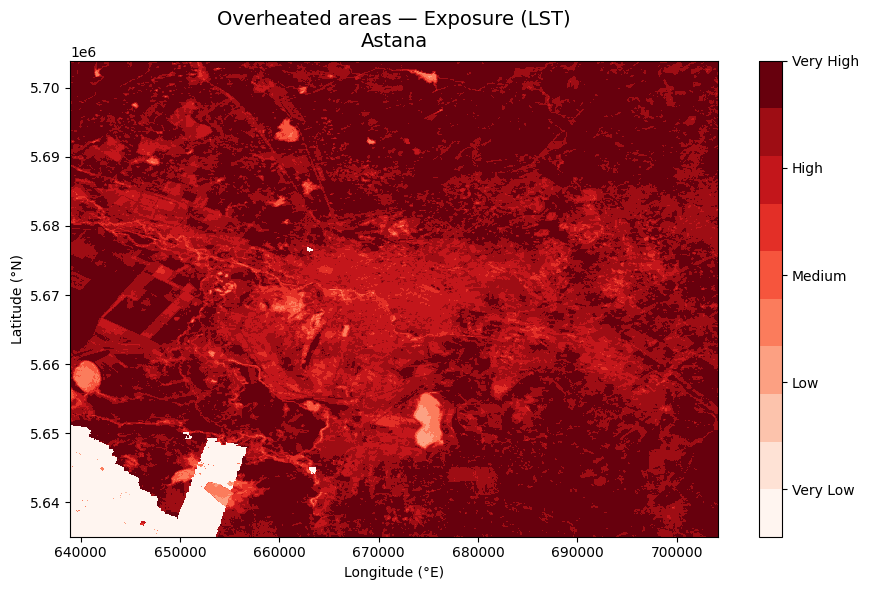

In [8]:
L8_ds   = xr.open_dataset(stack_path)
L8_max  = L8_ds.max(dim="band", skipna=True, keep_attrs=True)["band_data"]
lstbbox = L8_ds.rio.bounds()   


def reclassify_ge(array, bins, values):
    """Reclassify array: value[i] for bins[i-1] <= x < bins[i]."""
    out = np.zeros_like(array)
    out[array < bins[0]] = values[0]
    for i in range(len(bins) - 1):
        out[(array >= bins[i]) & (array < bins[i + 1])] = values[i + 1]
    out[array >= bins[-1]] = values[-1]
    return out


lc_class    = reclassify_ge(L8_max.values, LST_BINS, LST_VALUES)
lc_class_da = xr.DataArray(lc_class, coords=L8_max.coords, dims=L8_max.dims)

fig, ax = plt.subplots(figsize=(9, 6))
cmap_lst = plt.get_cmap("Reds", 10)
im = lc_class_da.plot(ax=ax, cmap=cmap_lst, add_colorbar=False)
cbar = fig.colorbar(im, ax=ax, ticks=[1, 3.25, 5.5, 7.75, 10])
cbar.ax.set_yticklabels(["Very Low", "Low", "Medium", "High", "Very High"], size=10)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title(f"Overheated areas — Exposure (LST)\n{LOCATION_NAME}", size=14, pad=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exposure_LST_classified.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5: Vulnerable Population Data (WorldPop)

### Manual download instructions — WorldPop Hub

1. Go to **https://hub.worldpop.org/geodata/listing?id=29**
2. Select **Kazakhstan** and year **2020**
3. Download the following files (male `m` and female `f`, age groups 1, 65, 70, 75, 80):

| File | Description |
|---|---|
| `kaz_f_1_2020.tif` | Female, age 0–1 |
| `kaz_m_1_2020.tif` | Male, age 0–1 |
| `kaz_f_65_2020.tif` | Female, age 65–70 |
| `kaz_m_65_2020.tif` | Male, age 65–70 |
| `kaz_f_70_2020.tif` | Female, age 70–75 |
| `kaz_m_70_2020.tif` | Male, age 70–75 |
| `kaz_f_75_2020.tif` | Female, age 75–80 |
| `kaz_m_75_2020.tif` | Male, age 75–80 |
| `kaz_f_80_2020.tif` | Female, age 80+ |
| `kaz_m_80_2020.tif` | Male, age 80+ |

4. Place all `.tif` files in: `Heatwave_risk_KZ/data/population/`


In [9]:
pop_files = list(POP_DIR.glob("kaz_*.tif"))
print(f"Found {len(pop_files)} WorldPop file(s) in {POP_DIR}")
if not pop_files:
    print("⚠ No WorldPop files found. Follow the download instructions above.")
for f in sorted(pop_files):
    print(f"  {f.name}")

Found 1 WorldPop file(s) in Heatwave_risk_KZ\data\population
  kaz_ppp_2020.tif


### Process population data


In [10]:
pop_stack_path = DATA_DIR / "Population_raster_stack.tif"

if pop_stack_path.exists():
    print(f"Cached: {pop_stack_path.name}")
    pop = xr.open_dataset(pop_stack_path)["band_data"].squeeze()
else:
    pop = xr.open_mfdataset(
        [str(f) for f in pop_files],
        chunks="auto",
        concat_dim="band",
        combine="nested",
    )["band_data"]

    pop = pop.rio.clip_box(
        minx=lstbbox[0], miny=lstbbox[1],
        maxx=lstbbox[2], maxy=lstbbox[3],
        crs="EPSG:4326",
    )
    pop = pop.sum(dim="band", skipna=True, keep_attrs=True)
    pop.rio.to_raster(pop_stack_path)
    print(f"Saved: {pop_stack_path.name}")

Cached: Population_raster_stack.tif


### Classify population (Vulnerability Layer)


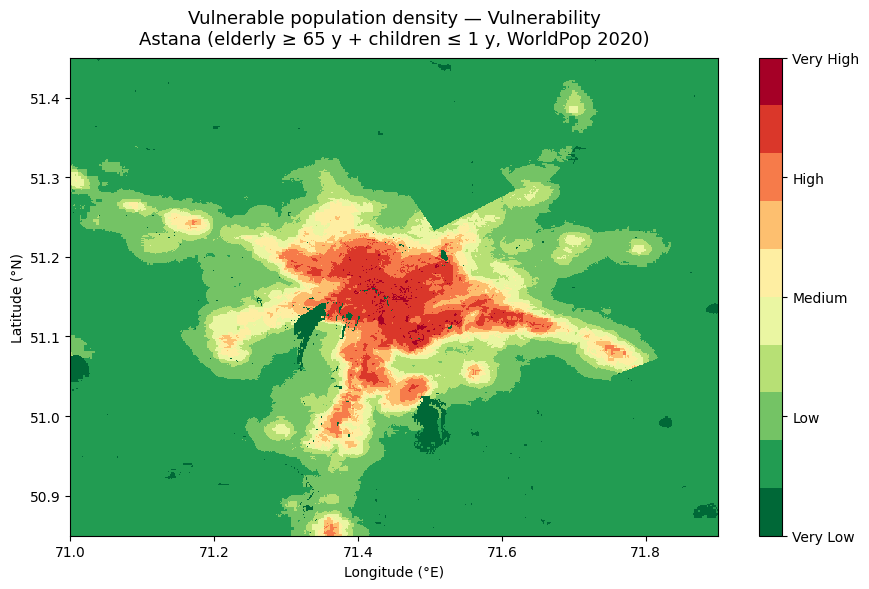

In [11]:
def reclassify_gt(array, bins, values):
    out = np.zeros_like(array)
    out[array <= bins[0]] = values[0]
    for i in range(len(bins) - 1):
        out[(array > bins[i]) & (array <= bins[i + 1])] = values[i + 1]
    out[array > bins[-1]] = values[-1]
    return out


n_bins    = 9
pop_min   = float(np.nanmin(pop))
pop_max   = float(np.nanmax(pop))
bin_width = (pop_max - pop_min) / n_bins
pop_bins  = [pop_min + i * bin_width for i in range(n_bins)]
pop_vals  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

pop_class    = reclassify_gt(pop.values, bins=pop_bins, values=pop_vals)
pop_class_da = xr.DataArray(pop_class, coords=pop.coords, dims=pop.dims)

fig, ax = plt.subplots(figsize=(9, 6))
cmap_pop = plt.get_cmap("RdYlGn_r", 10)
im = pop_class_da.plot(ax=ax, cmap=cmap_pop, add_colorbar=False)
cbar = fig.colorbar(im, ax=ax, ticks=[1, 3.25, 5.5, 7.75, 10])
cbar.ax.set_yticklabels(["Very Low", "Low", "Medium", "High", "Very High"], size=10)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title(
    f"Vulnerable population density — Vulnerability\n"
    f"{LOCATION_NAME} (elderly \u2265 65 y + children \u2264 1 y, WorldPop 2020)",
    size=13, pad=10,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "vulnerability_population_classified.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Side-by-side comparison: Exposure vs Vulnerability


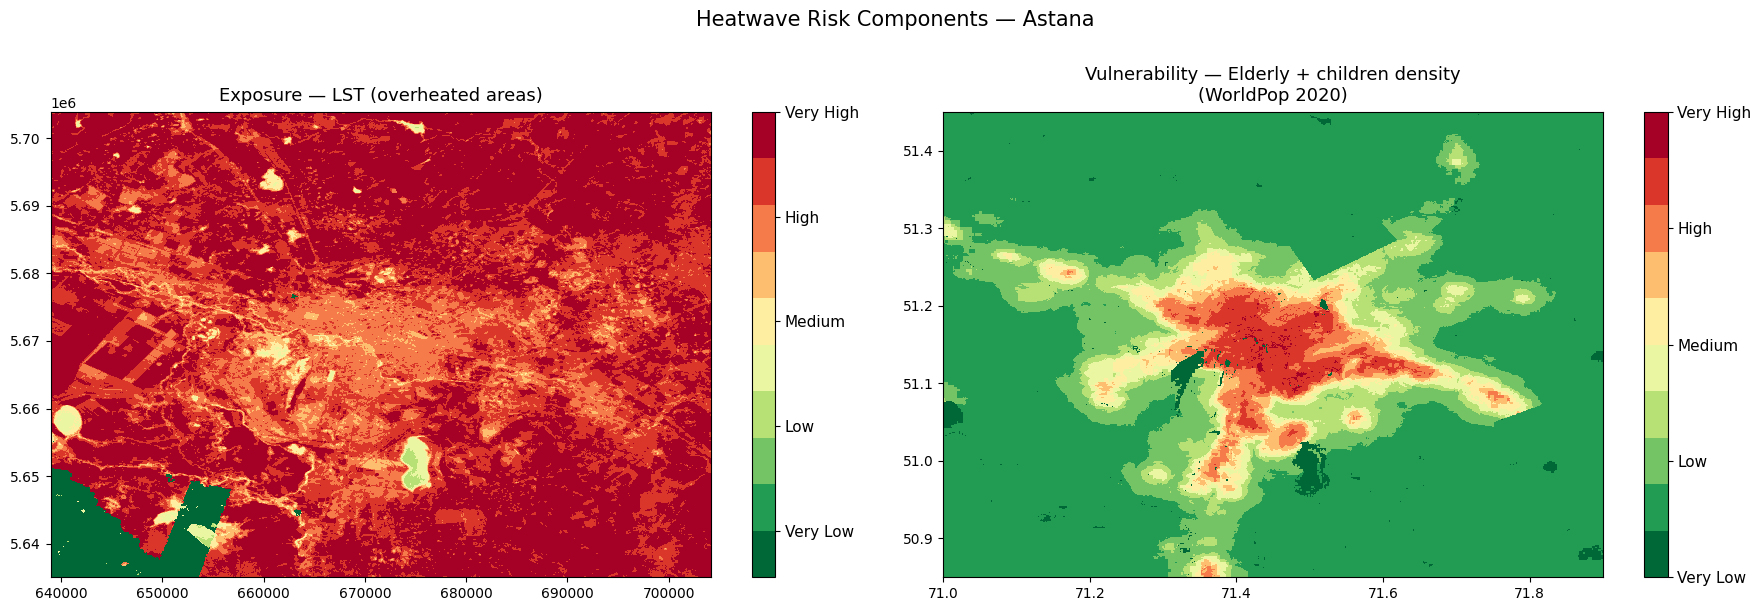

In [12]:
fig, axes = plt.subplots(ncols=2, figsize=(18, 6))
cmap_rv = plt.get_cmap("RdYlGn_r", 10)

im1 = lc_class_da.plot(ax=axes[0], cmap=cmap_rv, add_colorbar=False)
cb1 = fig.colorbar(im1, ax=axes[0], ticks=[1, 3.25, 5.5, 7.75, 10])
cb1.ax.set_yticklabels(["Very Low", "Low", "Medium", "High", "Very High"], size=11)
axes[0].set_title("Exposure — LST (overheated areas)", size=13, pad=8)
axes[0].set_xlabel(""); axes[0].set_ylabel("")

im2 = pop_class_da.plot(ax=axes[1], cmap=cmap_rv, add_colorbar=False)
cb2 = fig.colorbar(im2, ax=axes[1], ticks=[1, 3.25, 5.5, 7.75, 10])
cb2.ax.set_yticklabels(["Very Low", "Low", "Medium", "High", "Very High"], size=11)
axes[1].set_title(
    "Vulnerability — Elderly + children density\n(WorldPop 2020)",
    size=13, pad=8,
)
axes[1].set_xlabel(""); axes[1].set_ylabel("")

plt.suptitle(f"Heatwave Risk Components — {LOCATION_NAME}", size=15, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exposure_vs_vulnerability.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Step 6: OSM Critical Infrastructure

Downloads buildings and amenities from OpenStreetMap for the Astana bounding box, then filters to critical infrastructure features.
These are overlaid on the risk map as reference points.


In [13]:
osm_cache = OSM_DIR / f"{LOCATION_NAME}_CI_amenities.gpkg"

if osm_cache.exists():
    print(f"Cached: {osm_cache.name}")
    gdf_ci = gpd.read_file(osm_cache)
else:
    print("Downloading OSM features...")
    import shapely.geometry as shpgeom
    astana_poly = gpd.GeoDataFrame(
        geometry=[shpgeom.box(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)],
        crs="EPSG:4326"
    )
    gdf_osm = ox.features_from_polygon(
        astana_poly.iloc[0].geometry,
        tags={"building": True, "amenity": True},
    )
    cols = [c for c in ["building", "amenity"] if c in gdf_osm.columns]
    gdf_osm = gdf_osm[cols + ["geometry"]].copy()
    gdf_osm = gdf_osm.map(lambda x: str(x) if isinstance(x, list) else x)

    mask = (
        gdf_osm.get("building", pd.Series(dtype=str)).isin(CRIT_INFRA_TAGS) |
        gdf_osm.get("amenity",  pd.Series(dtype=str)).isin(CRIT_INFRA_TAGS)
    )
    gdf_ci = gdf_osm[mask].copy()

    if "amenity" not in gdf_ci.columns:
        gdf_ci["amenity"] = None
    if "building" in gdf_ci.columns:
        gdf_ci["amenity"] = gdf_ci["amenity"].fillna(gdf_ci["building"])

    gdf_ci["geometry"] = gdf_ci.geometry.apply(
        lambda g: g.centroid if g.geom_type != "Point" else g
    )
    gdf_ci = gdf_ci[gdf_ci.geom_type == "Point"][["amenity", "geometry"]]
    gdf_ci = gdf_ci.reset_index(drop=True)
    gdf_ci.to_file(osm_cache, driver="GPKG")
    print(f"Saved: {osm_cache.name}")

print(f"Critical infrastructure features: {len(gdf_ci)}")
print(gdf_ci["amenity"].value_counts().to_string())

Cached: Astana_CI_amenities.gpkg
Critical infrastructure features: 750
amenity
school          223
pharmacy        179
kindergarten    156
clinic           65
hospital         60
university       42
police           21
fire_station      4


## Step 7: Save Classified Layers


In [14]:
lc_class_da.rio.to_raster(RESULTS_DIR / "risk_LST.tif")
pop_class_da.rio.to_raster(RESULTS_DIR / "risk_pop.tif")
print(f"Saved risk_LST.tif and risk_pop.tif to {RESULTS_DIR}")

Saved risk_LST.tif and risk_pop.tif to Heatwave_risk_KZ\results


## Step 8: Calculate Risk Map

**Risk = Exposure class (LST) + Vulnerability class (population)**

Resulting scale: 2 (min, Very Low) → 20 (max, Very High)

Risk matrix logic:
- Both layers have 10 classes each
- Sum gives values 2–20
- Very Low risk areas: cool AND sparsely populated by vulnerable groups
- Very High risk areas: extremely hot AND densely populated by elderly/children


In [15]:
S2_files = sorted(RESULTS_DIR.glob("risk_*.tif"))

with rasterio.open(S2_files[0]) as src0:
    meta = src0.meta.copy()
meta.update(count=len(S2_files))

stack_risk_path = RESULTS_DIR / "risk_raster_stack.tif"
with rasterio.open(stack_risk_path, "w", **meta) as dst:
    for idx, layer in enumerate(S2_files, start=1):
        with rasterio.open(layer) as src:
            dst.write_band(idx, src.read(1))

risk_ds = xr.open_dataset(stack_risk_path)["band_data"]
risk    = risk_ds[0] + risk_ds[1]

risk.rio.to_raster(RESULTS_DIR / "heatwave_risk_astana.tif")
print(f"Risk map saved \u2192 {RESULTS_DIR / 'heatwave_risk_astana.tif'}")

Risk map saved → Heatwave_risk_KZ\results\heatwave_risk_astana.tif


## Step 9: Plot Risk Map


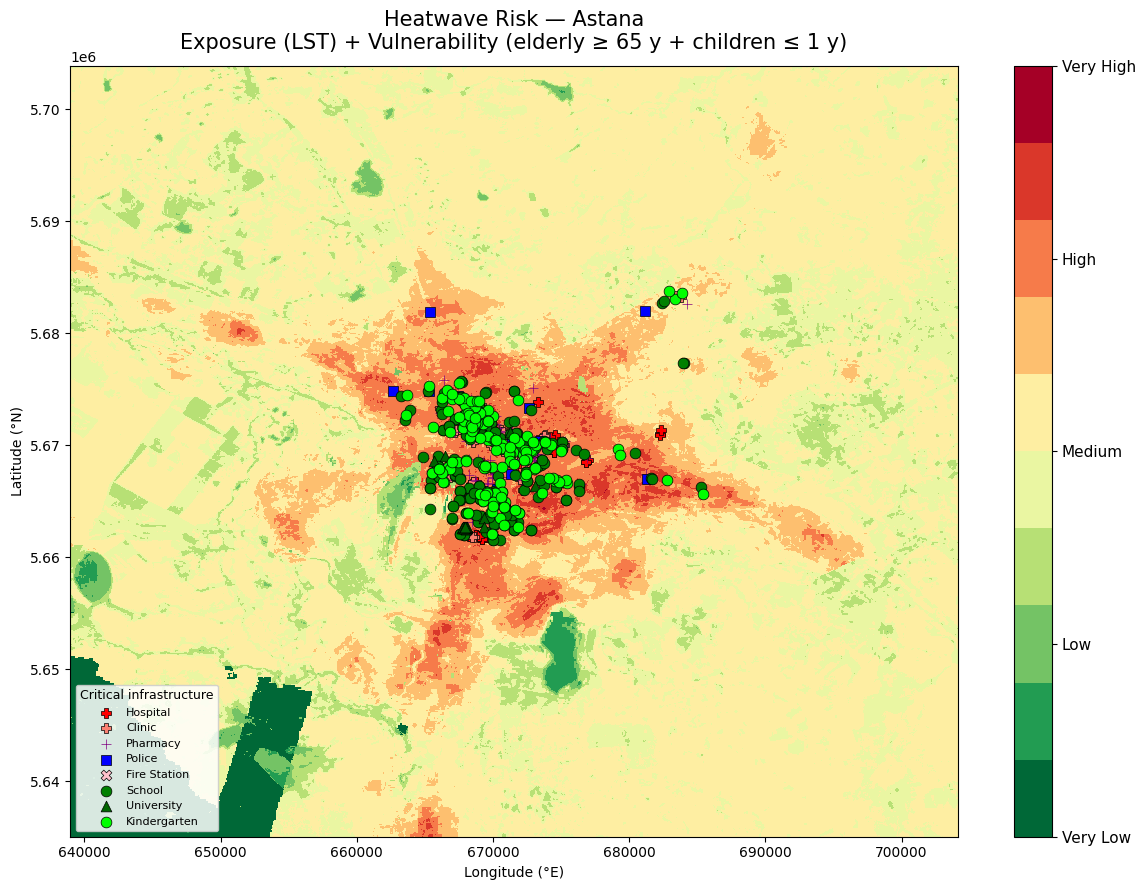

In [16]:
risk_crs   = risk.rio.crs
gdf_ci_prj = gdf_ci.to_crs(risk_crs)
minx, miny, maxx, maxy = risk.rio.bounds()

fig, ax = plt.subplots(figsize=(12, 9))
cmap_risk = plt.get_cmap("RdYlGn_r", 10)

im = risk.plot(
    ax=ax, cmap=cmap_risk, add_colorbar=False,
    vmin=2, vmax=20,
)
cbar = fig.colorbar(im, ax=ax, ticks=[2, 6.5, 11, 15.5, 20])
cbar.ax.set_yticklabels(
    ["Very Low", "Low", "Medium", "High", "Very High"], size=11
)

for amenity_type, style in CRIT_MARKERS.items():
    subset = gdf_ci_prj[gdf_ci_prj["amenity"] == amenity_type]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset.geometry.x, subset.geometry.y,
        marker=style["marker"], c=style["color"],
        s=60, zorder=5, label=amenity_type.replace("_", " ").title(),
        edgecolors="black", linewidths=0.5,
    )

ax.legend(
    loc="lower left", fontsize=8, framealpha=0.85,
    title="Critical infrastructure", title_fontsize=9,
)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title(
    f"Heatwave Risk — {LOCATION_NAME}\n"
    f"Exposure (LST) + Vulnerability (elderly \u2265 65 y + children \u2264 1 y)",
    size=15, pad=12,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatwave_risk_map.png", dpi=150, bbox_inches="tight")
plt.show()

### Risk map with OpenStreetMap basemap


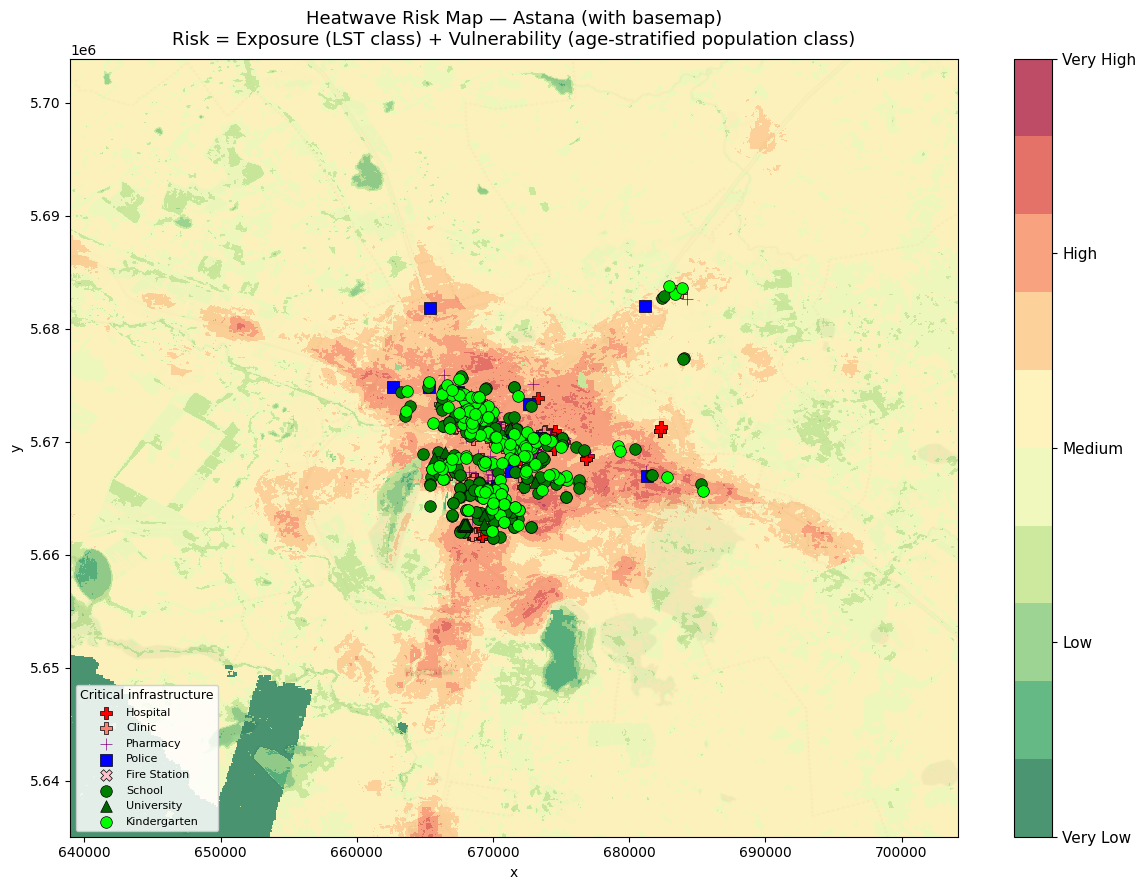

In [17]:
fig, ax = plt.subplots(figsize=(12, 9))

im = risk.plot(
    ax=ax, cmap=cmap_risk, add_colorbar=False,
    vmin=2, vmax=20, alpha=0.70,
)
cbar = fig.colorbar(im, ax=ax, ticks=[2, 6.5, 11, 15.5, 20])
cbar.ax.set_yticklabels(
    ["Very Low", "Low", "Medium", "High", "Very High"], size=11
)

for amenity_type, style in CRIT_MARKERS.items():
    subset = gdf_ci_prj[gdf_ci_prj["amenity"] == amenity_type]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset.geometry.x, subset.geometry.y,
        marker=style["marker"], c=style["color"],
        s=70, zorder=6, label=amenity_type.replace("_", " ").title(),
        edgecolors="black", linewidths=0.5,
    )

try:
    ctx.add_basemap(
        ax, crs=str(risk_crs),
        source=ctx.providers.CartoDB.Positron,
        attribution=False,
    )
except Exception:
    print("Basemap unavailable — check internet connection or contextily installation")

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.legend(
    loc="lower left", fontsize=8, framealpha=0.85,
    title="Critical infrastructure", title_fontsize=9,
)
ax.set_title(
    f"Heatwave Risk Map — {LOCATION_NAME} (with basemap)\n"
    f"Risk = Exposure (LST class) + Vulnerability (age-stratified population class)",
    size=13, pad=10,
)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "heatwave_risk_map_basemap.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## Conclusions

The risk map identifies areas in Astana where high land surface temperature
(exposure) coincides with high density of elderly and young-child population
(vulnerability). Dark red areas should be prioritised for heat mitigation
measures.

### Key caveats

- **LST is surface temperature, not air temperature.** Surface values are
  typically 10–15 °C higher than air temperature on clear sunny days. The
  classification thresholds reflect this. Do not compare directly with the
  air-temperature thresholds used in the hazard notebook.
- **WorldPop is modelled population.** Distributions are based on 2020
  census-derived models, not direct counts. Local municipality data (if
  available) would reduce uncertainty.
- **Landsat revisit is 8–16 days.** Not every extreme heat event is captured.
  Using multiple years of June–August images improves representativeness.
- **This is a historical risk snapshot.** To translate to future risk,
  combine with the projected increase in heatwave frequency from the hazard
  notebook (HWI / HWF / HWTL trends under SSP3-7.0).
- **Urban heat island effect.** The 30 m Landsat resolution captures
  intra-urban variation (parks vs. concrete), which coarse climate model data
  cannot. This workflow is designed precisely to add this local dimension.


## References

- RSLab (2024). Landsat LST portal. https://rslab.gr/Landsat_LST.html
- WorldPop (2020). Age-structured population, Kazakhstan.
  https://hub.worldpop.org/geodata/listing?id=29
- OpenStreetMap contributors (2024). Data via osmnx.
- Parastatidis et al. (2017). Online Global LST from Landsat.
  *Remote Sensing*, 9(12), 1208. DOI: 10.3390/rs9121208
- Nazarian et al. (2022). Integrated Assessment of Urban Overheating.
  *Earth's Future*, 10(9). DOI: 10.1029/2022EF002682
- US EPA (2024). Heat Island Effect. https://www.epa.gov/heatislands


## Authors

- Original CLIMAAX workflow: Martin Kuban, Milan Kalas, Milica Aleksic
  (KAJO services); review by Natalia Aleksandrova (Deltares)
